# Phase 11 — Le Conseil mélange vos mots

## Objectifs

- Prouver, chiffres en main, que le mécanisme d'attention de la phase 10 rend exactement le même
  résultat (par mot) sur un relevé et sur ce même relevé mélangé — il ne fait pas la différence entre
  une phrase et son désordre.
- Corriger, **sans toucher au mécanisme d'attention lui-même** : injecter la position directement dans
  les vecteurs d'entrée, avant le calcul.
- Refaire la même preuve après correction, et montrer qu'elle ne tient plus.


## 1. Imports

In [1]:
from pathlib import Path
import csv
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn


## 2. Configuration et reprise du relevé de la phase 10

In [2]:
SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE11_DIR = OUTPUT_DIR / "phase_11_encodage_position"
PHASE11_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime", "city", "state", "country", "shape",
    "duration_seconds", "duration_hours_min", "comments",
    "date_posted", "latitude", "longitude",
]

D_MODEL = 32
RELEVE_CHOISI_INDEX = 100  # meme releve qu'en phase 10

lignes_valides = []
with open(DATA_PATH, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)
df = pd.DataFrame(lignes_valides, columns=COLUMNS)
df["comments_clean"] = df["comments"].fillna("").astype(str).str.strip()

def tokenizer(texte):
    return re.findall(r"[a-z0-9]+", str(texte).lower())

texte_choisi = df.loc[RELEVE_CHOISI_INDEX, "comments_clean"]
tokens = tokenizer(texte_choisi)
longueur = len(tokens)

print(f"Relevé (index {RELEVE_CHOISI_INDEX}) : {texte_choisi!r}")
print(f"Jetons ({longueur}) : {tokens}")


Relevé (index 100) : 'Oval shaped with lights all around it in a haze with several smaller lights flying all around it.'
Jetons (18) : ['oval', 'shaped', 'with', 'lights', 'all', 'around', 'it', 'in', 'a', 'haze', 'with', 'several', 'smaller', 'lights', 'flying', 'all', 'around', 'it']


## 3. Le mécanisme de la phase 10, à l'identique (il ne change pas dans cette phase)

In [3]:
vocabulaire = {"<UNK>": 0}
for token in tokens:
    if token not in vocabulaire:
        vocabulaire[token] = len(vocabulaire)

embedding = nn.Embedding(len(vocabulaire), D_MODEL)
couche_question = nn.Linear(D_MODEL, D_MODEL, bias=False)
couche_etiquette = nn.Linear(D_MODEL, D_MODEL, bias=False)
couche_contenu = nn.Linear(D_MODEL, D_MODEL, bias=False)

def attention(vecteurs):
    """Mecanisme de la phase 10, inchange : ne sait rien de l'ordre des positions."""
    questions = couche_question(vecteurs)
    etiquettes = couche_etiquette(vecteurs)
    contenus = couche_contenu(vecteurs)
    scores = questions @ etiquettes.T / (D_MODEL ** 0.5)
    poids = torch.softmax(scores, dim=-1)
    sortie = poids @ contenus
    return sortie, poids

def ids_pour(liste_tokens):
    return torch.tensor([vocabulaire[t] for t in liste_tokens], dtype=torch.long)


## 4. Preuve : le désordre ne change rien (avant correction)

On tire une permutation aléatoire des positions, on mélange le relevé, on repasse le mécanisme de
la phase 10 sur la version mélangée, puis on **réaligne** la sortie mélangée dans l'ordre d'origine
(chaque mot retrouve sa position de départ). Si le mécanisme ne voit pas l'ordre, la sortie réalignée
doit être rigoureusement identique à la sortie calculée sur la phrase correcte.

In [4]:
torch.manual_seed(SEED)
permutation = torch.randperm(longueur)
inverse_permutation = torch.argsort(permutation)

tokens_melanges = [tokens[i] for i in permutation.tolist()]
print(f"Phrase correcte : {' '.join(tokens)}")
print(f"Phrase mélangée : {' '.join(tokens_melanges)}")

vecteurs_originaux = embedding(ids_pour(tokens))
vecteurs_melanges = embedding(ids_pour(tokens_melanges))

sortie_originale_avant, poids_originaux_avant = attention(vecteurs_originaux)
sortie_melangee_avant, poids_melanges_avant = attention(vecteurs_melanges)

# On remet la sortie melangee dans l'ordre d'origine, mot par mot.
sortie_melangee_realignee_avant = sortie_melangee_avant[inverse_permutation]

ecart_avant = (sortie_originale_avant - sortie_melangee_realignee_avant).abs().max().item()
print(f"\nÉcart maximal, sortie correcte vs sortie mélangée-réalignée, AVANT correction : {ecart_avant:.10f}")


Phrase correcte : oval shaped with lights all around it in a haze with several smaller lights flying all around it
Phrase mélangée : it all flying in a around with lights all several smaller around with it lights haze oval shaped

Écart maximal, sortie correcte vs sortie mélangée-réalignée, AVANT correction : 0.0000000894


## 5. La correction : encodage de position, injecté avant le calcul

Le mécanisme d'attention (`attention()`, section 3) ne change pas d'une ligne. Ce qui change, c'est
ce qu'on lui donne en entrée : un vecteur de position, un par emplacement de la séquence, mélangé au
vecteur du mot **avant** qu'il ne devienne question, étiquette ou contenu. On utilise l'encodage
sinusoïdal classique — il n'a pas besoin d'être appris pour faire la preuve.

In [5]:
def encodage_position_sinusoidal(longueur_sequence, dimension):
    positions = torch.arange(longueur_sequence).unsqueeze(1).float()
    frequences = torch.exp(
        torch.arange(0, dimension, 2).float() * (-np.log(10000.0) / dimension)
    )
    encodage = torch.zeros(longueur_sequence, dimension)
    encodage[:, 0::2] = torch.sin(positions * frequences)
    encodage[:, 1::2] = torch.cos(positions * frequences)
    return encodage

encodage_position = encodage_position_sinusoidal(longueur, D_MODEL)
print(f"Forme de l'encodage de position : {tuple(encodage_position.shape)}")


Forme de l'encodage de position : (18, 32)


## 6. Refaire la même preuve, après correction

In [6]:
# Le mot a la position j (dans la phrase donnee) recoit le vecteur de position j,
# quel que soit le mot qui occupe cette position : c'est la ou l'ordre entre desormais dans le calcul.
vecteurs_originaux_position = vecteurs_originaux + encodage_position
vecteurs_melanges_position = vecteurs_melanges + encodage_position  # positions 0..n-1, pour la phrase MELANGEE

sortie_originale_apres, poids_originaux_apres = attention(vecteurs_originaux_position)
sortie_melangee_apres, poids_melanges_apres = attention(vecteurs_melanges_position)

sortie_melangee_realignee_apres = sortie_melangee_apres[inverse_permutation]

ecart_apres = (sortie_originale_apres - sortie_melangee_realignee_apres).abs().max().item()
print(f"Écart maximal, sortie correcte vs sortie mélangée-réalignée, APRÈS correction : {ecart_apres:.6f}")

print(f"\nRésumé :")
print(f"  Écart AVANT correction : {ecart_avant:.10f}  (nul ou indistinguable de zéro)")
print(f"  Écart APRÈS correction : {ecart_apres:.6f}  (nettement non nul)")


Écart maximal, sortie correcte vs sortie mélangée-réalignée, APRÈS correction : 0.139459

Résumé :
  Écart AVANT correction : 0.0000000894  (nul ou indistinguable de zéro)
  Écart APRÈS correction : 0.139459  (nettement non nul)


## 7. Les deux matrices de poids côte à côte, avant et après

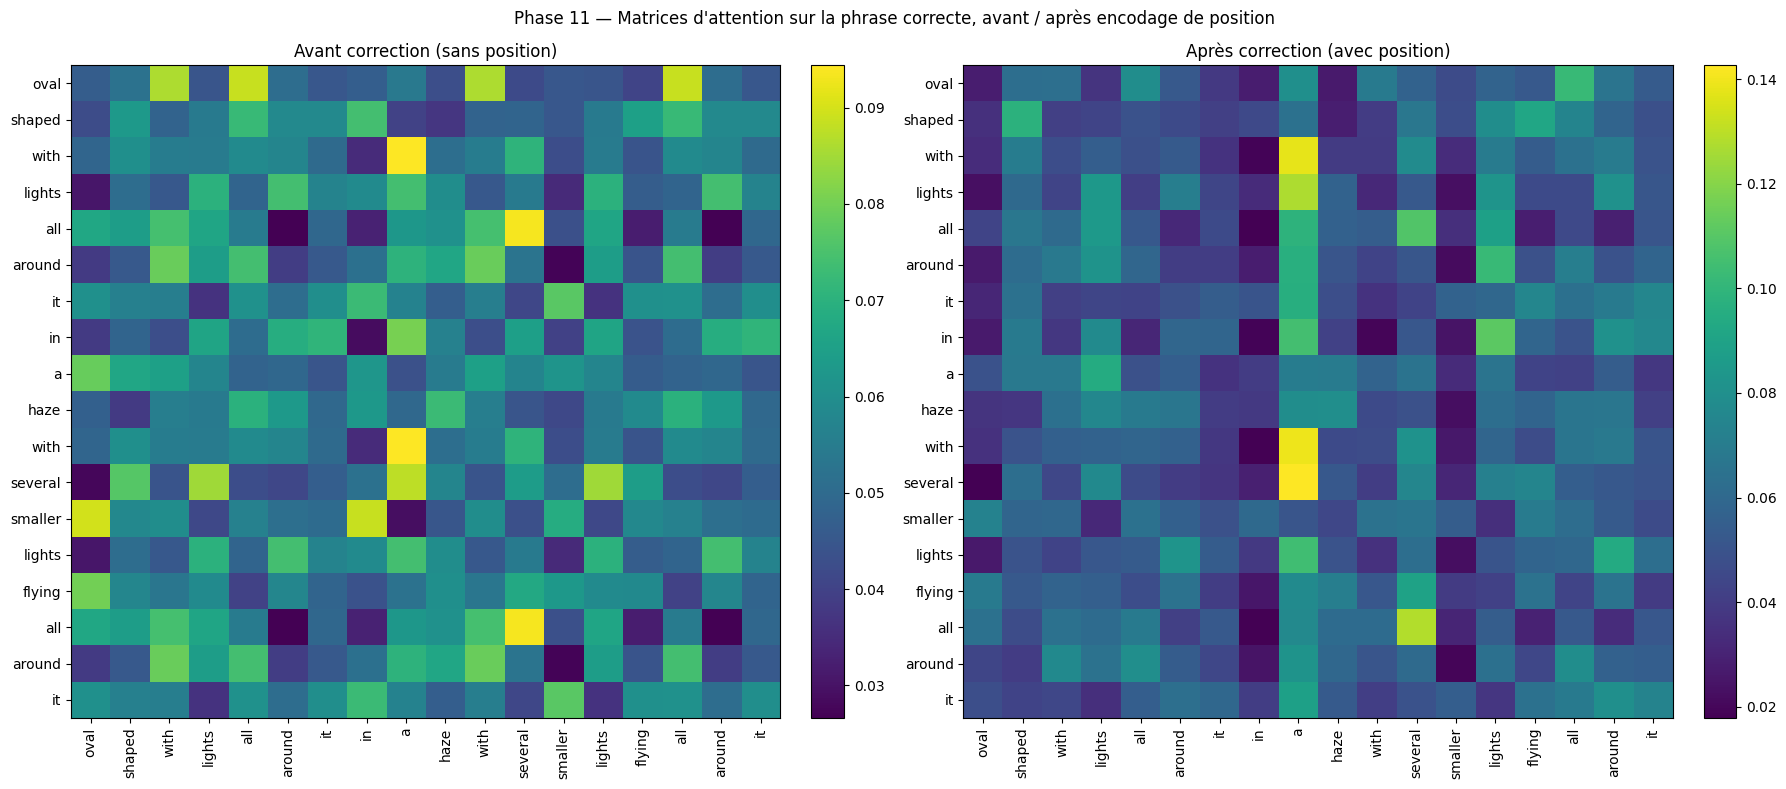

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, matrice, titre in [
    (axes[0], poids_originaux_avant, "Avant correction (sans position)"),
    (axes[1], poids_originaux_apres, "Après correction (avec position)"),
]:
    im = ax.imshow(matrice.detach().numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(longueur))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticks(range(longueur))
    ax.set_yticklabels(tokens)
    ax.set_title(titre)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Phase 11 — Matrices d'attention sur la phrase correcte, avant / après encodage de position")
plt.tight_layout()
plt.savefig(PHASE11_DIR / "matrices_avant_apres.png", dpi=150)
plt.show()


## 8. Où l'information manquante a été injectée, et pourquoi là

L'ordre a été injecté **dans les vecteurs d'entrée eux-mêmes**, avant qu'ils ne deviennent question,
étiquette ou contenu — pas après le calcul des scores, et pas seulement dans un sous-ensemble de ces
trois rôles. Deux raisons à ce choix précis :

1. Le mécanisme d'attention (section 3) compare des questions à des étiquettes et mélange des
   contenus ; il ne reçoit jamais d'indice de position en argument. La seule façon de le rendre
   sensible à l'ordre sans toucher à une seule de ses lignes est de faire porter cette information par
   ce qu'il reçoit déjà en entrée.
2. Injecter la position **avant** les trois projections garantit qu'elle infuse les trois rôles à la
   fois : la question d'un mot peut désormais dépendre de sa position, son étiquette aussi, et le
   contenu qu'il propose aussi. L'injecter seulement après (par exemple en l'ajoutant à la sortie)
   n'aurait changé ni les scores, ni les poids d'attention — seulement une sortie déjà calculée sans
   tenir compte de l'ordre, ce qui ne répare rien.

## 9. Export

In [8]:
resume_phase11 = pd.DataFrame([{
    "index_releve": RELEVE_CHOISI_INDEX,
    "nombre_jetons": longueur,
    "ecart_avant_correction": ecart_avant,
    "ecart_apres_correction": ecart_apres,
    "permutation": str(permutation.tolist()),
}])
resume_phase11.to_csv(PHASE11_DIR / "resume_phase11.csv", index=False)
resume_phase11


,index_releve,nombre_jetons,ecart_avant_correction,ecart_apres_correction,permutation
0,100,18,8.940697e-08,0.139459,"[6, 15, 14, 7, 8, 16, 10, 3, 4, 11, 12, 5, 2, ..."
